# Первый неоптимизированный вариант

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations
import time
import networkx as nx

In [ ]:
# создаем граф
nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] # вершины
edges = [ # ребра
    (1, 2), (1, 3),
    (2, 3), (2, 4), (2, 5),
    (3, 6), (3, 7),
    (4, 7),
    (5, 7),
    (6, 7), (6, 8), (6, 9), (6, 10), (6, 13),
    (6, 8), (6, 9), (6, 10),
    (7, 8), (7, 9),
    (9, 13), (9, 15),
    (10, 11), (10, 12),
    (11, 15),
    (12, 2), (12, 3), (12, 5),
    (13, 7), (13, 4),
    (14, 15)
]


def is_independent_set(node_set): # проверка является ли множество независимым (когда между двумя вершинами нет ребра)
    for node1, node2 in combinations(node_set, 2): # комбинации вершин по 2 без повторений и порядок не важен
        if (node1, node2) in edges or (node2, node1) in edges:
            return False
    return True


def find_maximum_independent_set(): # находим макс независимое множество
    max_set = []
    for size in range(2, len(nodes) + 1): # перебираем кол-во вершин, не может быть меньше 2 независимых
        for combination in combinations(nodes, size): # составляем комбинации из вершин длины от 2 до 7
            if is_independent_set(combination):
                if len(combination) > len(max_set):
                    max_set = list(combination)
    return max_set


start_time = time.time() # проверка на время
max_independent_set = find_maximum_independent_set()
end_time = time.time()

print(f"Вершин: {len(nodes)}, Ребер: {len(edges)}")
print(f"Максимальное независимое множество: {max_independent_set}")
print(f"Размер: {len(max_independent_set)} узла(ов)")
print(f"Время: {end_time - start_time:.10f} сек")

# оценка по времени: O(2^n × n² × E)
# 2^n — общее количество комбинаций вершин (все подмножества)
# n^2 — проверка каждой комбинации (перебор всех пар вершин)
# E — проверка ребра через список (линейный поиск по всем рёбрам)
# Для n = 15: ~1.0-1.5 сек для n = 30: ~43 часа

Вершин: 15, Ребер: 30
Максимальное независимое множество: [1, 4, 5, 8, 9, 10, 14]
Размер: 7 узла(ов)
Время: 0.1027021408 сек


# Второй вариант с тем же графом, но оптимизирован

In [ ]:
nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
edges = [
    (1, 2), (1, 3),
    (2, 3), (2, 4), (2, 5),
    (3, 6), (3, 7),
    (4, 7),
    (5, 7),
    (6, 7), (6, 8), (6, 9), (6, 10), (6, 13),
    (6, 8), (6, 9), (6, 10),
    (7, 8), (7, 9),
    (9, 13), (9, 15),
    (10, 11), (10, 12),
    (11, 15),
    (12, 2), (12, 3), (12, 5),
    (13, 7), (13, 4),
    (14, 15)
]

edges_set = set() # создаем множество ребер для быстрой проверки вхождения ребра в него
for u, v in edges:
    edges_set.add((u, v))
    edges_set.add((v, u))


def is_independent_set(node_set, edges_set): # проверка является ли множество независимым
    for node1, node2 in combinations(node_set, 2):
        if (node1, node2) in edges_set:  # проверка вхождения ребра, благодаря set заменили O(n) на O(1)
            return False
    return True


def find_maximum_independent_set(nodes, edges_set): # находим макс независимое множество
    max_set = []
    n = len(nodes)
    for size in range(n, 0, -1): # идем от большего к меньшему размеру множества
        for combination in combinations(nodes, size):
            if is_independent_set(combination, edges_set):
                max_set = list(combination)
                return max_set # если такое нашли, то оно автоматически самое большое (тк мы идем по убыванию)
    return max_set


start_time = time.time()
max_independent_set = find_maximum_independent_set(nodes, edges_set)
end_time = time.time()

print(f"Вершин: {len(nodes)}, Ребер: {len(edges)}")
print(f"Максимальное независимое множество: {sorted(max_independent_set)}")
print(f"Размер: {len(max_independent_set)} узла(ов)")
print(f"Время: {end_time - start_time:.6f} сек.")

# оценка по времени: O(2^n × n²)
# 2^n — общее количество комбинаций вершин (все подмножества)
# n^2 — проверка каждой комбинации (перебор всех пар вершин)
# Проверка ребра через set: O(1) вместо O(E)
# Нисходящий поиск (от n к 1): если нашли , то сразу return и не проверяем меньшие размеры

Вершин: 15, Ребер: 30
Максимальное независимое множество: [1, 4, 5, 8, 9, 10, 14]
Размер: 7 узла(ов)
Время: 0.018691 сек.


# Оптимизированный вариант с генерацией графов малого мира

Пример с 15 вершинами и 30 ребрами

In [34]:
# cоздаём граф малого мира
G = nx.watts_strogatz_graph(n=15, k=4, p=0.4)
# количество вершин, количество соседей в кольце, вероятность пересоединения ребра

nodes = list(G.nodes()) # вершины
edges_set = set(G.edges()) # рёбра; здесь можно сразу использовать set и не делать проверку на обратное ребро (то есть например не менять (2,1) на (1,2)), потому что
# G.edges() выводит ребра в виде (число меньше правого, число больше левого) напр (2, 6) (9, 20), (3, 4) и тп, то есть одной проверки здесь достаточно

def is_independent_set(node_set, edges_set): # проверка является ли множество независимым
    for node1, node2 in combinations(node_set, 2):
        if (node1, node2) in edges_set:  # проверка вхождения ребра, благодаря set заменили O(n) на O(1)
            return False
    return True


def find_maximum_independent_set(nodes, edges_set): # находим макс независимое множество
    max_set = []
    n = len(nodes)
    for size in range(n, 0, -1): # идем от большего к меньшему размеру множества
        for combination in combinations(nodes, size):
            if is_independent_set(combination, edges_set):
                max_set = list(combination)
                return max_set # если такое нашли, то оно автоматически самое большое (тк мы идем по убыванию)
    return max_set

start_time = time.time()
max_independent_set = find_maximum_independent_set(nodes, edges_set)
end_time = time.time()

print(f"Вершин: {len(nodes)}, Ребер: {len(edges_set)}")
print(f"Максимальное независимое множество: {sorted(max_independent_set)}")
print(f"Размер: {len(max_independent_set)} узла(ов)")
print(f"Время: {end_time - start_time:.6f} сек.")

# оценка по времени: O(2^n × n²)
# 2^n — общее количество комбинаций вершин (все подмножества)
# n^2 — проверка каждой комбинации (перебор всех пар вершин)
# Проверка ребра через set: O(1) вместо O(E)
# Нисходящий поиск (от n к 1): если нашли , то сразу return и не проверяем меньшие размеры
# G.edges() возвращает рёбра в каноническом порядке (меньший узел первым) достаточно одной проверки (не переворачиваем вершины)
# сразу set(G.edges()) вместо цикла for

Вершин: 15, Ребер: 30
Максимальное независимое множество: [1, 3, 6, 7, 9, 10, 12]
Размер: 7 узла(ов)
Время: 0.010307 сек.


In [ ]:
# пример как выводятся ребра графа малого мира
G = nx.watts_strogatz_graph(n=15, k=4, p=0.4)

nodes = list(G.nodes()) # вершины
edges_set = set(G.edges()) # рёбра
print(edges_set)

{(3, 4), (3, 7), (4, 6), (3, 10), (5, 7), (0, 2), (8, 9), (0, 5), (0, 14), (1, 3), (10, 12), (13, 14), (4, 5), (3, 12), (5, 9), (4, 11), (0, 1), (9, 13), (0, 13), (11, 13), (1, 14), (7, 9), (6, 7), (6, 10), (12, 14), (8, 10), (2, 3), (1, 7), (2, 6), (7, 8)}


Пример с 30 вершинами и 60 ребрами

In [ ]:
# cоздаём граф малого мира
G = nx.watts_strogatz_graph(n=30, k=4, p=0.4)
# количество вершин, количество соседей в кольце, вероятность пересоединения ребра

nodes = list(G.nodes()) # вершины
edges_set = set(G.edges()) # рёбра; здесь можно сразу использовать set и не делать проверку на обратное ребро (то есть например не менять (2,1) на (1,2)), потому что
# G.edges() выводит ребра в виде (число меньше правого, число больше левого) напр (2, 6) (9, 20), (3, 4) и тп, то есть одной проверки здесь достаточно

def is_independent_set(node_set, edges_set): # проверка является ли множество независимым
    for node1, node2 in combinations(node_set, 2):
        if (node1, node2) in edges_set:  # проверка вхождения ребра, благодаря set заменили O(n) на O(1)
            return False
    return True


def find_maximum_independent_set(nodes, edges_set): # находим макс независимое множество
    max_set = []
    n = len(nodes)
    for size in range(n, 0, -1): # идем от большего к меньшему размеру множества
        for combination in combinations(nodes, size):
            if is_independent_set(combination, edges_set):
                max_set = list(combination)
                return max_set # если такое нашли, то оно автоматически самое большое (тк мы идем по убыванию)
    return max_set

start_time = time.time()
max_independent_set = find_maximum_independent_set(nodes, edges_set)
end_time = time.time()

print(f"Вершин: {len(nodes)}, Ребер: {len(edges_set)}")
print(f"Максимальное независимое множество: {sorted(max_independent_set)}")
print(f"Размер: {len(max_independent_set)} узла(ов)")
print(f"Время: {end_time - start_time:.6f} сек.")

Вершин: 30, Ребер: 60
Максимальное независимое множество: [1, 2, 6, 7, 9, 10, 14, 17, 19, 22, 25, 26, 28, 29]
Размер: 14 узла(ов)
Время: 492.365174 сек.


# Графики

n=10: среднее=0.0003 сек, СКО=0.0000
n=11: среднее=0.0009 сек, СКО=0.0005
n=12: среднее=0.0013 сек, СКО=0.0001
n=13: среднее=0.0027 сек, СКО=0.0004
n=14: среднее=0.0054 сек, СКО=0.0008
n=15: среднее=0.0113 сек, СКО=0.0010
n=16: среднее=0.0323 сек, СКО=0.0101
n=17: среднее=0.0836 сек, СКО=0.0094
n=18: среднее=0.1840 сек, СКО=0.0214
n=19: среднее=0.2080 сек, СКО=0.0338
n=20: среднее=0.4042 сек, СКО=0.0783
n=21: среднее=1.0161 сек, СКО=0.2443
n=22: среднее=2.1886 сек, СКО=0.4799
n=23: среднее=4.2826 сек, СКО=0.5279
n=24: среднее=8.9977 сек, СКО=1.7544
n=25: среднее=17.3033 сек, СКО=2.1815


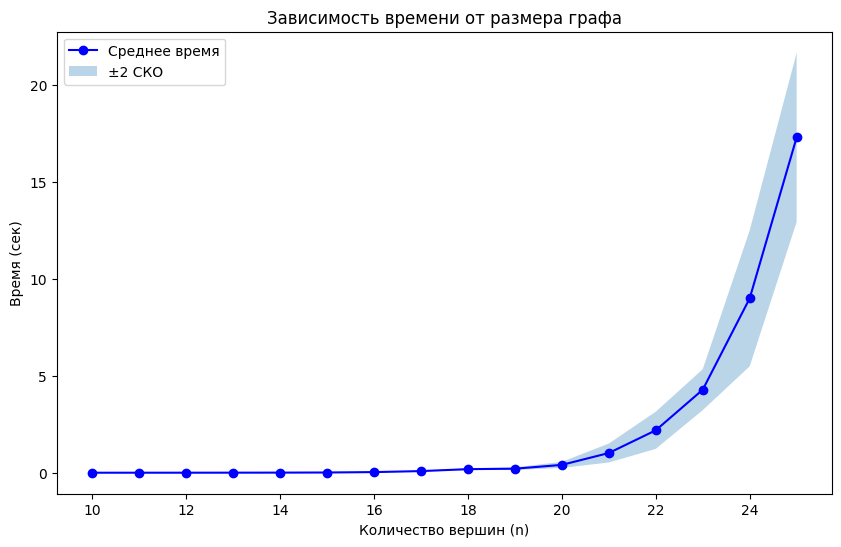

In [50]:
# Время от n
n_values = range(10, 26)  # от 10 до 25 вершин
avg_times = []
std_times = []

for n in n_values:
    times = []
    for i in range(10):  # 5 запусков для каждого n
        G = nx.watts_strogatz_graph(n=n, k=4, p=0.4)
        nodes = list(G.nodes())
        edges_set = set(G.edges())

        start = time.time()
        mis = find_maximum_independent_set(nodes, edges_set)
        times.append(time.time() - start)

    avg_times.append(np.mean(times))
    std_times.append(np.std(times))
    print(f"n={n}: среднее={np.mean(times):.4f} сек, СКО={np.std(times):.4f}")

# Рисуем график
plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_times, 'bo-', label='Среднее время')
plt.fill_between(n_values,
                  np.array(avg_times) - 2*np.array(std_times),
                  np.array(avg_times) + 2*np.array(std_times),
                  alpha=0.3, label='±2 СКО')
plt.xlabel('Количество вершин (n)')
plt.ylabel('Время (сек)')
plt.title('Зависимость времени от размера графа')
plt.legend()
plt.show()

/tmp/ipykernel_344/3698595258.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


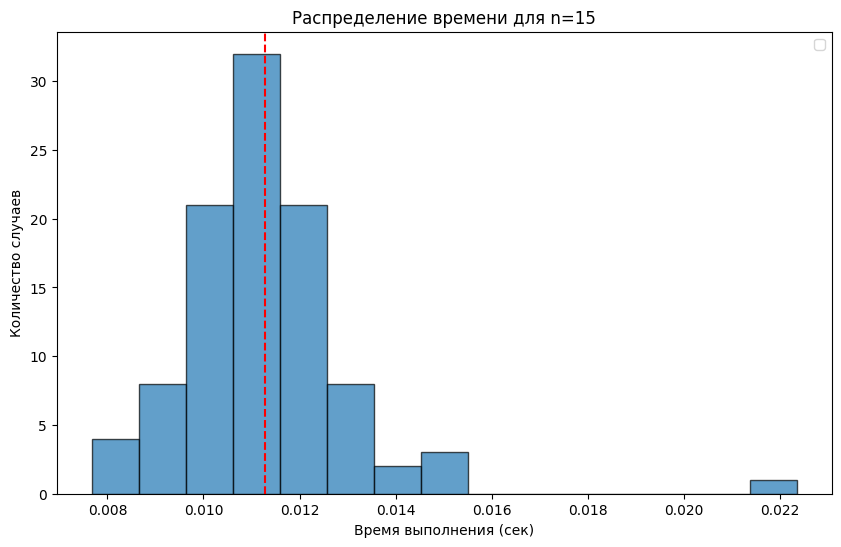


Статистика для n=15:
Среднее: 0.0113 сек
СКО: 0.0018 сек


In [48]:
# Гистограмма для n=15 (просто оптимальное кол-во вершин)
n = 15
times = []
for i in range(100):  # 100 запусков
    G = nx.watts_strogatz_graph(n=n, k=4, p=0.4)
    nodes = list(G.nodes())
    edges_set = set(G.edges())

    start = time.time()
    mis = find_maximum_independent_set(nodes, edges_set)
    times.append(time.time() - start)

plt.figure(figsize=(10, 6))
plt.hist(times, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(times), color='red', linestyle='--')
plt.xlabel('Время выполнения (сек)')
plt.ylabel('Количество случаев') # сколько раз из всех запусков алгоритм выполнился за определенное время
plt.title(f'Распределение времени для n={n}')
plt.show()

print(f"Статистика для n={n}:")
print(f"Среднее: {np.mean(times):.4f} сек")
print(f"СКО: {np.std(times):.4f} сек")